In [4]:
# imports
# %matplotlib widget

import os
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import shap
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import fdrcorrection

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import make_scorer, precision_score, recall_score, classification_report, ConfusionMatrixDisplay, f1_score, make_scorer, RocCurveDisplay
from itertools import combinations

def precision_class_0(y_true, y_pred):
    return precision_score(y_true, y_pred, average=None)[0]

def precision_class_1(y_true, y_pred):
    return precision_score(y_true, y_pred, average=None)[1]

def recall_class_0(y_true, y_pred):
    return recall_score(y_true, y_pred, average=None)[0]

def recall_class_1(y_true, y_pred):
    return recall_score(y_true, y_pred, average=None)[1]

import warnings
import anndata
import scanpy as sc

In [5]:
os.getcwd()

'/workspace/paper/ML/XAI'

In [6]:
os.chdir("../Store/")
os.getcwd()

'/workspace/paper/ML/Store'

In [7]:
# Load the three CSV files
PBMC_BCELLS = pd.read_csv("./PBMC_BCELLS_2DATASET/gene_BCELLS_PBMC.csv")
CSF_CD4 = pd.read_csv("./CD4_CSF_SAMU/gene_CD4_CSF.csv")
CSF_BCELLS = pd.read_csv("./CSF_BCELLS/gene_BCELLS_CSF.csv")

# Check the loaded data
print("PBMC_BCELLS shape:", PBMC_BCELLS.shape)
print("CSF_CD4 shape:", CSF_CD4.shape)
print("CSF_BCELLS shape:", CSF_BCELLS.shape)

# Preview the first few rows
print("\nPBMC_BCELLS preview:")
print(PBMC_BCELLS.head())
print("\nCSF_CD4 preview:")
print(CSF_CD4.head())
print("\nCSF_BCELLS preview:")
print(CSF_BCELLS.head())


PBMC_BCELLS shape: (17410, 2)
CSF_CD4 shape: (17236, 2)
CSF_BCELLS shape: (16505, 2)

PBMC_BCELLS preview:
       Gene Category
0      A1BG      NaN
1  A1BG-AS1      NaN
2      A1CF      NaN
3       A2M      NaN
4     A2ML1      NaN

CSF_CD4 preview:
       Gene Category
0      A1BG      NaN
1  A1BG-AS1      NaN
2      A1CF     SHAP
3       A2M      DEA
4     A2ML1     SHAP

CSF_BCELLS preview:
       Gene Category
0      A1BG      NaN
1  A1BG-AS1      NaN
2      A1CF      NaN
3       A2M     SHAP
4   A2M-AS1      NaN


In [8]:
import pandas as pd
import joblib

# Load the full gene list from microarray
full_microarray = joblib.load("./MICROARRAY/dataset_genes_list.pkl")

# Define the gene lists
both_microarray = ['HLA-DRB1', 'HLA-DRB5']
dea_microarray = ['MBP', 'HLA-DRB1', 'GABPA', 'GFI1', 'HLA-DRB5']
shap_microarray = ['HLA-DRB1', 'HLA-DRB5', 'EGR1', 'IL2RA', 'IL1B']

# Create the dataframe
MICROARRAY = pd.DataFrame({'Gene': full_microarray})

# Function to assign category
def assign_category(gene):
    if gene in both_microarray:
        return 'Both'
    elif gene in dea_microarray:
        return 'DEA'
    elif gene in shap_microarray:
        return 'SHAP'
    else:
        return None

# Apply the function to assign categories
MICROARRAY['Category'] = MICROARRAY['Gene'].apply(assign_category)

print("MICROARRAY shape:", MICROARRAY.shape)
print("\nMICROARRAY preview:")
print(MICROARRAY.head(20))
print("\nCategory counts:")
print(MICROARRAY['Category'].value_counts(dropna=False))


MICROARRAY shape: (6673, 2)

MICROARRAY preview:
       Gene Category
0     TRAK2     None
1   MARCHF5     None
2      AVIL     None
3    CLSTN1     None
4    TAPBPL     None
5    TRIM38     None
6     GDF11     None
7    TBXA2R     None
8     SPAST     None
9      MCM3     None
10     OSBP     None
11  SLC50A1     None
12     USP1     None
13   ZNF222     None
14     ATG3     None
15    ZFPL1     None
16    ERP44     None
17  HAPSTR1     None
18  TMSB15B     None
19    EHMT1     None

Category counts:
Category
None    6665
SHAP       3
DEA        3
Both       2
Name: count, dtype: int64


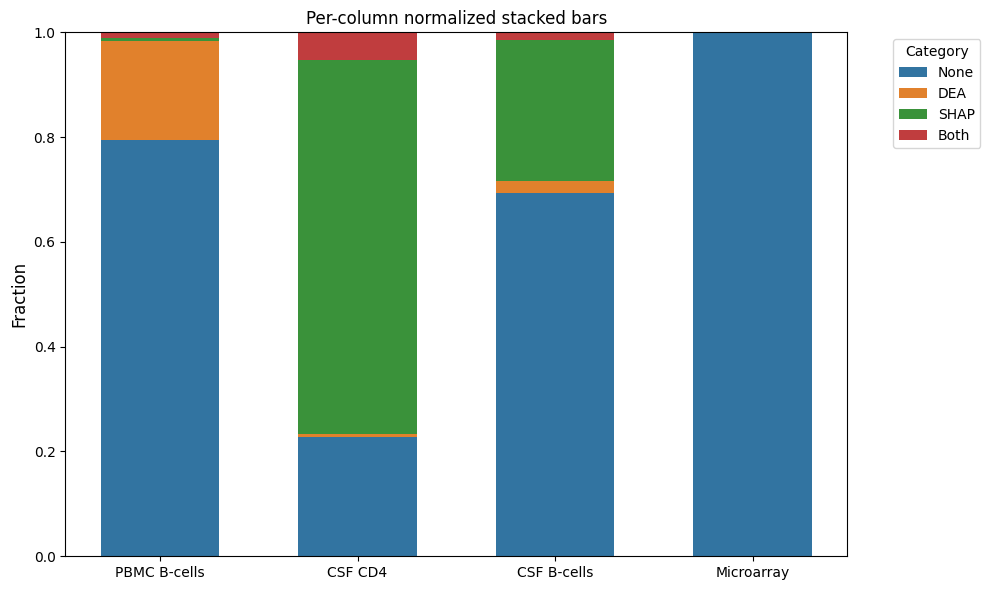

Plot saved as 'stacked_barplot_with_microarray.png'


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assuming all dataframes are already loaded:
# PBMC_BCELLS, CSF_CD4, CSF_BCELLS, MICROARRAY

# Function to count categories
def count_categories(df):
    # Replace NaN with 'None' for counting
    df_copy = df.copy()
    df_copy['Category'] = df_copy['Category'].fillna('None')
    
    # Count each category
    counts = df_copy['Category'].value_counts()
    
    # Ensure all categories are present
    for cat in ['None', 'DEA', 'SHAP', 'Both']:
        if cat not in counts:
            counts[cat] = 0
    
    return counts

# Get counts for each dataset
pbmc_counts = count_categories(PBMC_BCELLS)
csf_cd4_counts = count_categories(CSF_CD4)
csf_bcells_counts = count_categories(CSF_BCELLS)
microarray_counts = count_categories(MICROARRAY)

# Calculate fractions (normalize to 1.0)
pbmc_fractions = pbmc_counts / pbmc_counts.sum()
csf_cd4_fractions = csf_cd4_counts / csf_cd4_counts.sum()
csf_bcells_fractions = csf_bcells_counts / csf_bcells_counts.sum()
microarray_fractions = microarray_counts / microarray_counts.sum()

# Prepare data for plotting
categories = ['None', 'DEA', 'SHAP', 'Both']
datasets = ['PBMC B-cells', 'CSF CD4', 'CSF B-cells', 'Microarray']

# Create matrix of fractions
data_matrix = np.array([
    [pbmc_fractions.get(cat, 0) for cat in categories],
    [csf_cd4_fractions.get(cat, 0) for cat in categories],
    [csf_bcells_fractions.get(cat, 0) for cat in categories],
    [microarray_fractions.get(cat, 0) for cat in categories]
]).T

# Create the stacked bar plot
fig, ax = plt.subplots(figsize=(10, 6))

# Colors matching the image
colors = ['#3274A1', '#E1812C', '#3A923A', '#C03D3E']  # Blue, Orange, Green, Red
x = np.arange(len(datasets))
width = 0.6

# Create stacked bars
bottom = np.zeros(len(datasets))
for i, (category, color) in enumerate(zip(categories, colors)):
    ax.bar(x, data_matrix[i], width, label=category, bottom=bottom, color=color)
    bottom += data_matrix[i]

# Customize plot
ax.set_ylabel('Fraction', fontsize=12)
ax.set_title('Per-column normalized stacked bars', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylim(0, 1.0)
ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('stacked_barplot_with_microarray.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'stacked_barplot_with_microarray.png'")


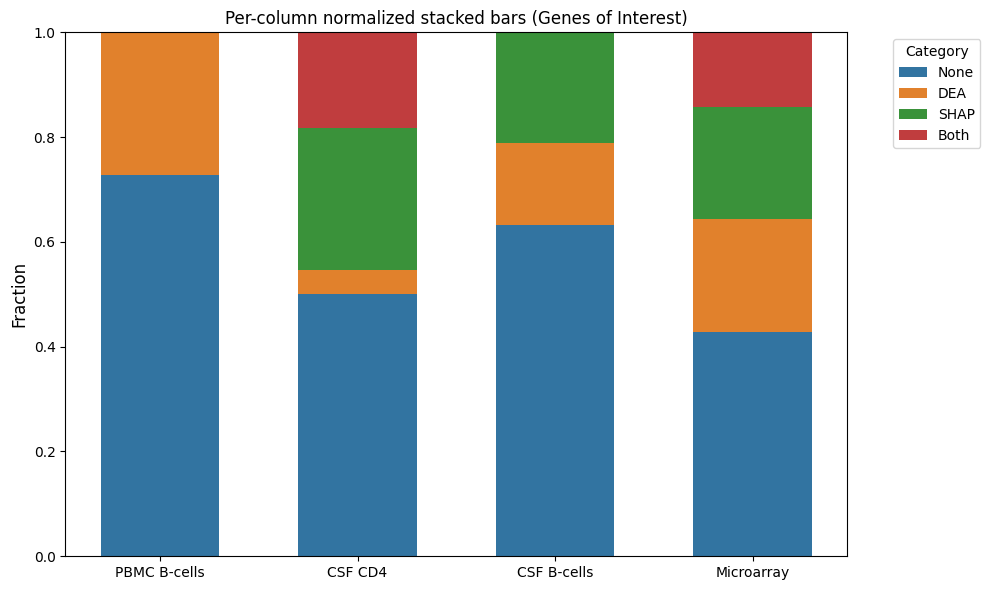

Plot saved as 'stacked_barplot_genes_of_interest.png'

Filtered dataset sizes:
PBMC B-cells: 22 genes
CSF CD4: 22 genes
CSF B-cells: 19 genes
Microarray: 14 genes


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define genes of interest
genes_of_interest = [
    "GABPA", "CTCF", "EGR1", "YY1", "SPI1", "CLOCK", "ARNTL", "BACH1",
    "GFI1", "IFNB1", "MOG", "MBP", "CD42", "IFNG", "IL17A", "IL10",
    "TNF", "IL1B", "IL6", "TNFRSF1A", "CYP27B1", "IL7R", "HLA-DRB1",
    "HLA-DRB5", "IL2RA"
]

# Filter each dataframe to only include genes of interest
PBMC_BCELLS_filtered = PBMC_BCELLS[PBMC_BCELLS['Gene'].isin(genes_of_interest)]
CSF_CD4_filtered = CSF_CD4[CSF_CD4['Gene'].isin(genes_of_interest)]
CSF_BCELLS_filtered = CSF_BCELLS[CSF_BCELLS['Gene'].isin(genes_of_interest)]
MICROARRAY_filtered = MICROARRAY[MICROARRAY['Gene'].isin(genes_of_interest)]

# Function to count categories
def count_categories(df):
    # Replace NaN with 'None' for counting
    df_copy = df.copy()
    df_copy['Category'] = df_copy['Category'].fillna('None')
    
    # Count each category
    counts = df_copy['Category'].value_counts()
    
    # Ensure all categories are present
    for cat in ['None', 'DEA', 'SHAP', 'Both']:
        if cat not in counts:
            counts[cat] = 0
    
    return counts

# Get counts for each dataset (filtered)
pbmc_counts = count_categories(PBMC_BCELLS_filtered)
csf_cd4_counts = count_categories(CSF_CD4_filtered)
csf_bcells_counts = count_categories(CSF_BCELLS_filtered)
microarray_counts = count_categories(MICROARRAY_filtered)

# Calculate fractions (normalize to 1.0)
pbmc_fractions = pbmc_counts / pbmc_counts.sum()
csf_cd4_fractions = csf_cd4_counts / csf_cd4_counts.sum()
csf_bcells_fractions = csf_bcells_counts / csf_bcells_counts.sum()
microarray_fractions = microarray_counts / microarray_counts.sum()

# Prepare data for plotting
categories = ['None', 'DEA', 'SHAP', 'Both']
datasets = ['PBMC B-cells', 'CSF CD4', 'CSF B-cells', 'Microarray']

# Create matrix of fractions
data_matrix = np.array([
    [pbmc_fractions.get(cat, 0) for cat in categories],
    [csf_cd4_fractions.get(cat, 0) for cat in categories],
    [csf_bcells_fractions.get(cat, 0) for cat in categories],
    [microarray_fractions.get(cat, 0) for cat in categories]
]).T

# Create the stacked bar plot
fig, ax = plt.subplots(figsize=(10, 6))

# Colors matching the image
colors = ['#3274A1', '#E1812C', '#3A923A', '#C03D3E']  # Blue, Orange, Green, Red
x = np.arange(len(datasets))
width = 0.6

# Create stacked bars
bottom = np.zeros(len(datasets))
for i, (category, color) in enumerate(zip(categories, colors)):
    ax.bar(x, data_matrix[i], width, label=category, bottom=bottom, color=color)
    bottom += data_matrix[i]

# Customize plot
ax.set_ylabel('Fraction', fontsize=12)
ax.set_title('Per-column normalized stacked bars (Genes of Interest)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylim(0, 1.0)
ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('stacked_barplot_genes_of_interest.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'stacked_barplot_genes_of_interest.png'")
print(f"\nFiltered dataset sizes:")
print(f"PBMC B-cells: {len(PBMC_BCELLS_filtered)} genes")
print(f"CSF CD4: {len(CSF_CD4_filtered)} genes")
print(f"CSF B-cells: {len(CSF_BCELLS_filtered)} genes")
print(f"Microarray: {len(MICROARRAY_filtered)} genes")


### Nuova Lista Geni Interessanti

In [11]:
df = pd.read_csv("mrna.csv", sep=";")
print(df.shape)

(1175, 22)


In [12]:
# starting to filter out
df = df[df["Species"] == "Homo sapiens"]
print(df.shape)

(624, 22)


In [13]:
#all kind of samples
print(df["Detected Sample"].unique())

['cerebral tissue' 'blood' nan 'brain' 'blood and brain'
 'peripheral blood' 'Serum' 'peripheral blood samples'
 'EDTA anticoagulated peripheral blood' 'PBMC' 'peripheral whole blood'
 'whole blood' 'PBMCs'
 'fresh frozen blocks from MS brains, normal white matter' 'serum'
 'brain tissue or cells' 'peripheral venous puncture'
 'heparinized venous blood' 'white blood cells' 'total blood'
 'CSF and plasma' 'fresh blood' 'peripheral blood lymphocytes,serum'
 'peripheral blood mononuclear cell' 'venous blood' 'plasma'
 'peripheral blood mononuclear cells (PBMCs)' 'blood samples'
 'Brain tissue' 'CSF' 'cortical gray matter' 'Peripheral blood'
 'Whole blood' 'peripheral blood;brain' 'Brain' 'PBL and CSF' 'meninges'
 'CSF/peripheral blood' 'cerebrospinal fluid' 'Blood'
 'cell-free cerebrospinal fluid' 'CSF and blood samples' 'blood,CSF'
 'tumor/normal adjacent tissues and various areas of brain tissues'
 'human astrocytes and in human umbilical vein endothelial cells'
 'splenocytes' 'DNA, blo

In [14]:
blood_samples = [
    'blood',
    'blood and brain',
    'peripheral blood',
    'Serum',
    'peripheral blood samples',
    'EDTA anticoagulated peripheral blood',
    'PBMC',
    'peripheral whole blood',
    'whole blood',
    'PBMCs',
    'serum',
    'peripheral venous puncture',
    'heparinized venous blood',
    'white blood cells',
    'total blood',
    'CSF and plasma',
    'fresh blood',
    'peripheral blood lymphocytes,serum',
    'peripheral blood mononuclear cell',
    'venous blood',
    'plasma',
    'peripheral blood mononuclear cells (PBMCs)',
    'blood samples',
    'Peripheral blood',
    'Whole blood',
    'peripheral blood;brain',
    'PBL and CSF',
    'CSF/peripheral blood',
    'Blood',
    'CSF and blood samples',
    'blood,CSF',
    'Peritoneal macrophages',
    'blood and CSF',
    'Peripheral blood、CFS']

csf_samples = [
    'CSF and plasma',
    'PBL and CSF',
    'CSF',
    'CSF/peripheral blood',
    'cerebrospinal fluid',
    'CSF and blood samples',
    'blood,CSF',
    'blood and CSF',
    'Peripheral blood、CFS'
]

blood = df[df["Detected Sample"].isin(blood_samples)]
csf = df[df["Detected Sample"].isin(csf_samples)]
print("blood:", blood.shape)
print("csf", csf.shape)

blood: (530, 22)
csf (28, 22)


In [15]:
blood = blood[blood['Disease'].str.contains('MS|multiple sclerosis|optic neuritis', case=False, na=False)]
csf = csf[csf['Disease'].str.contains('MS|multiple sclerosis|optic neuritis', case=False, na=False)]

In [16]:
print("blood:", blood.shape)
print("csf", csf.shape)

blood: (522, 22)
csf (28, 22)


In [17]:
print(blood.Disease.value_counts())
print(csf.Disease.value_counts())

Disease
MS                                                   517
optic neuritis (ON)                                    2
MS、hereditary spastic paraplegia                       1
multiple sclerosis, psoriasis and type 1 diabetes      1
HIVinfected、MS                                         1
Name: count, dtype: int64
Disease
MS      26
RRMS     2
Name: count, dtype: int64


In [18]:
blood.to_csv("blood_relevant_genes_from_silvia.csv")
csf.to_csv("csf_relevant_genes_from_silvia.csv")

In [19]:
# blood with aliases 
blood_alias = blood[["Official Symbol of Gene", "Also known as"]]
csf_alias = csf[["Official Symbol of Gene", "Also known as"]]

In [20]:
blood = blood[["Official Symbol of Gene"]]
csf = csf[["Official Symbol of Gene"]]
print(blood.head())
print(csf.head())

   Official Symbol of Gene
10                    CYBB
14                    IL17
23                    IL10
24                     LIF
25                     IL6
    Official Symbol of Gene
344                  ERVW-1
443                HLA-DPB1
444                HLA-DPA1
606                  MIR922
607                 MIR181C


Plot saved as 'blood_genes_distribution.png'

Filtered dataset sizes:
PBMC B-cells: 277 genes
Microarray: 166 genes


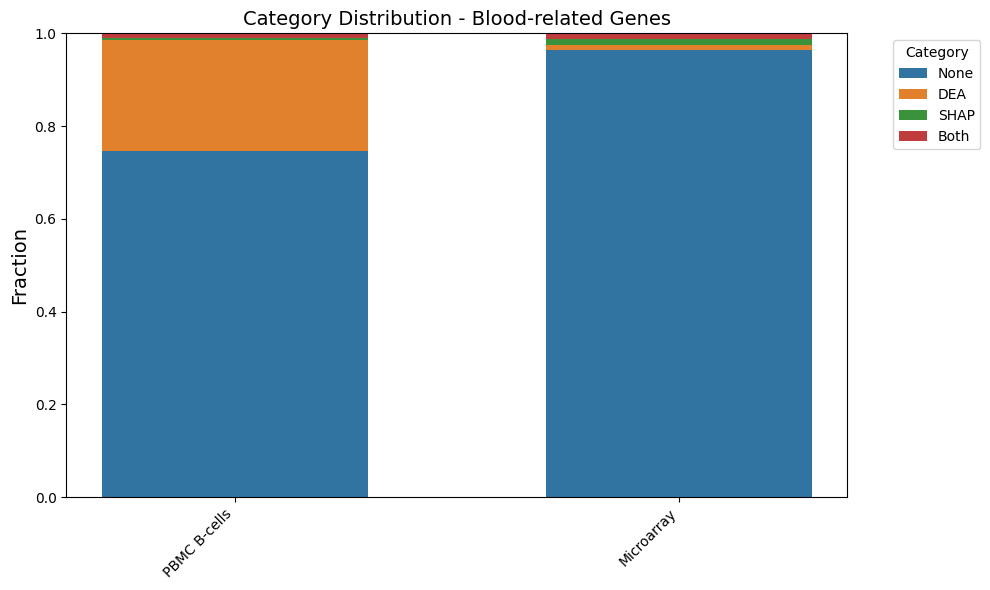

In [21]:
def plot_category_distribution(dataframes_dict, genes_of_interest, 
                               title='Per-column normalized stacked bars',
                               figsize=(10, 6), save_path=None, csv_path=None):
    """
    Create a stacked bar plot showing category distribution across multiple datasets.
    Also outputs a CSV with gene classifications.
    
    Parameters:
    -----------
    dataframes_dict : dict
        Dictionary with dataset names as keys and DataFrames as values
        Each DataFrame must have 'Gene' and 'Category' columns
    genes_of_interest : list
        List of genes to filter for
    title : str
        Plot title
    figsize : tuple
        Figure size (width, height)
    save_path : str, optional
        Path to save the figure. If None, doesn't save
    csv_path : str, optional
        Path to save the CSV with gene classifications. If None, doesn't save
    
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    filtered_counts : dict
        Dictionary with dataset names and their filtered gene counts
    classification_df : pd.DataFrame
        DataFrame with gene classifications across datasets
    """
    
    def count_categories(df):
        df_copy = df.copy()
        df_copy['Category'] = df_copy['Category'].fillna('None')
        counts = df_copy['Category'].value_counts()
        
        # Ensure all categories are present
        for cat in ['None', 'DEA', 'SHAP', 'Both']:
            if cat not in counts:
                counts[cat] = 0
        return counts
    
    # Filter and process each dataset
    filtered_dfs = {}
    fractions_dict = {}
    
    for name, df in dataframes_dict.items():
        filtered = df[df['Gene'].isin(genes_of_interest)]
        filtered_dfs[name] = filtered
        counts = count_categories(filtered)
        fractions_dict[name] = counts / counts.sum()
    
    # CREATE CLASSIFICATION DATAFRAME
    classification_data = []
    for gene in genes_of_interest:
        gene_row = {'Gene': gene}
        for name, df in filtered_dfs.items():
            gene_data = df[df['Gene'] == gene]
            if len(gene_data) > 0:
                category = gene_data['Category'].fillna('None').iloc[0]
            else:
                category = 'Not Found'
            gene_row[name] = category
        classification_data.append(gene_row)
    
    classification_df = pd.DataFrame(classification_data)
    
    # Save CSV only if path is provided
    if csv_path is not None:
        classification_df.to_csv(csv_path, index=False)
        print(f"Gene classifications saved as '{csv_path}'")
    
    # Prepare plotting data
    categories = ['None', 'DEA', 'SHAP', 'Both']
    colors = ['#3274A1', '#E1812C', '#3A923A', '#C03D3E']
    dataset_names = list(dataframes_dict.keys())
    
    data_matrix = np.array([
        [fractions_dict[name].get(cat, 0) for name in dataset_names]
        for cat in categories
    ])
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(dataset_names))
    width = 0.6
    bottom = np.zeros(len(dataset_names))
    
    for i, (category, color) in enumerate(zip(categories, colors)):
        ax.bar(x, data_matrix[i], width, label=category, 
               bottom=bottom, color=color)
        bottom += data_matrix[i]
    
    # Customize
    ax.set_ylabel('Fraction', fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(dataset_names, rotation=45, ha='right')
    ax.set_ylim(0, 1.0)
    ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved as '{save_path}'")
    
    # Print summary
    filtered_counts = {name: len(df) for name, df in filtered_dfs.items()}
    print("\nFiltered dataset sizes:")
    for name, count in filtered_counts.items():
        print(f"{name}: {count} genes")
    
    return fig, ax, filtered_counts, classification_df

# Usage:
datasets = {
    'PBMC B-cells': PBMC_BCELLS,
    'Microarray': MICROARRAY
}

fig, ax, counts, df = plot_category_distribution(
    datasets, 
    blood["Official Symbol of Gene"].tolist(),
    title='Category Distribution - Blood-related Genes',
    save_path='blood_genes_distribution.png'
)
plt.show()


Plot saved as 'csf_genes_distribution.png'

Filtered dataset sizes:
CSF_BCELLS: 19 genes
CSF_CD4: 20 genes


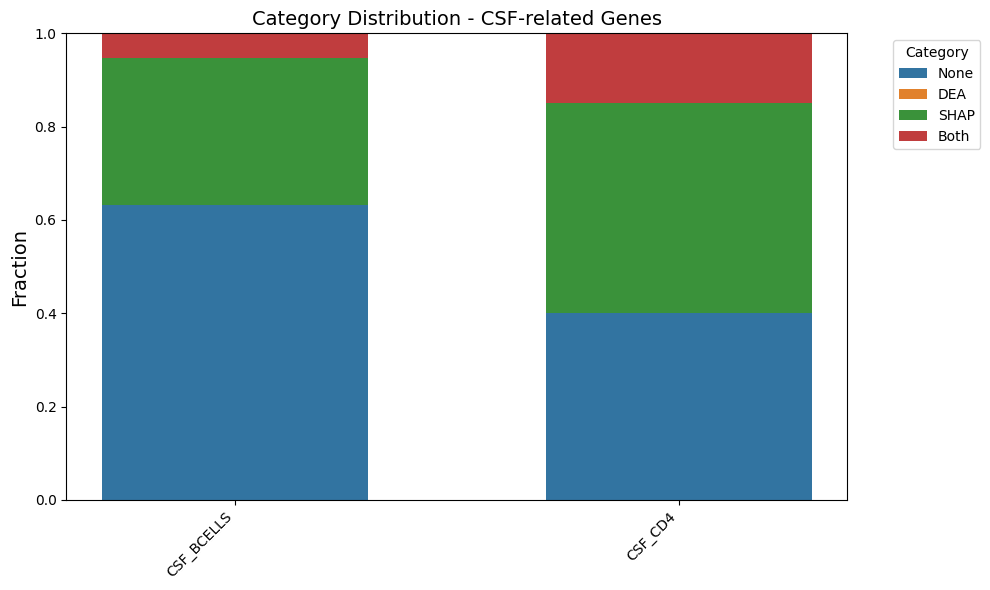

In [22]:
# Or for CSF genes:
datasets = {
    'CSF_BCELLS':CSF_BCELLS, 'CSF_CD4': CSF_CD4
}
fig, ax, counts, df = plot_category_distribution(
     datasets, 
     csf["Official Symbol of Gene"].tolist(),
     title='Category Distribution - CSF-related Genes',
     save_path='csf_genes_distribution.png', 
    
)

Gene classifications saved as 'csv_global.csv'
Plot saved as 'genes_distribution_merge.png'

Filtered dataset sizes:
CSF_BCELLS: 274 genes
CSF_CD4: 291 genes
PBMC B-cells: 286 genes
Microarray: 173 genes


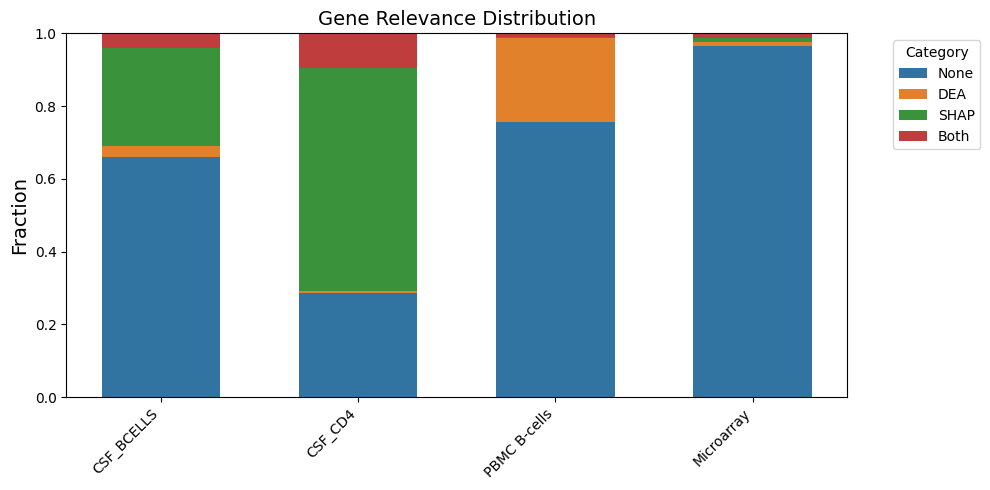

In [64]:
# Or for CSF genes:
datasets = {
    'CSF_BCELLS':CSF_BCELLS, 'CSF_CD4': CSF_CD4, 'PBMC B-cells': PBMC_BCELLS,
    'Microarray': MICROARRAY
}

fig, ax, counts, df= plot_category_distribution(
     datasets, 
     list(set(csf["Official Symbol of Gene"].tolist()).union(set(blood["Official Symbol of Gene"].tolist()))),
     title='Gene Relevance Distribution',
     save_path='genes_distribution_merge.png', csv_path="csv_global.csv",
     figsize=(10,5)
)

In [20]:
print(len(list(set(csf["Official Symbol of Gene"].tolist()).union(set(blood["Official Symbol of Gene"].tolist())))))

383


In [24]:
len(list(set(csf["Official Symbol of Gene"].tolist())))

26

Gene classifications saved as 'genes_classification.csv'
Plot saved as 'genes_distribution.png'

Filtered dataset sizes (genes found):
CSF_BCELLS: 274 genes
CSF_CD4: 291 genes
PBMC B-cells: 286 genes
Microarray: 173 genes


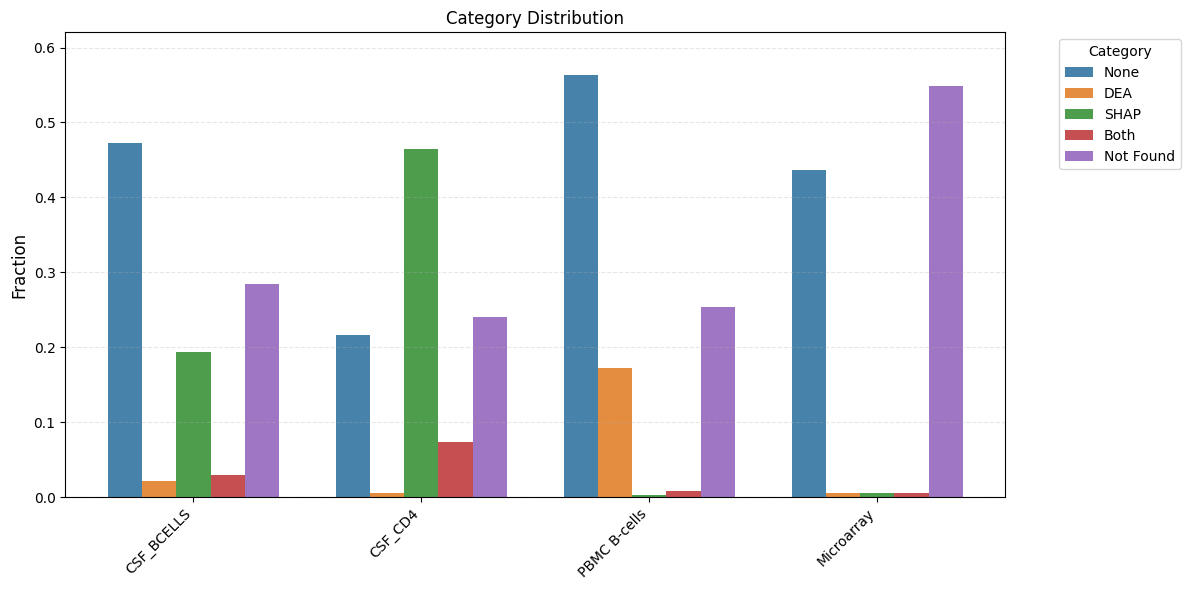

In [65]:
def plot_category_distribution(dataframes_dict, genes_of_interest, 
                               title='Per-column normalized grouped bars',
                               figsize=(12, 6), save_path=None, csv_path=None):
    """
    Create a grouped bar plot showing category distribution across multiple datasets.
    Also outputs a CSV with gene classifications.
    
    Parameters:
    -----------
    dataframes_dict : dict
        Dictionary with dataset names as keys and DataFrames as values
        Each DataFrame must have 'Gene' and 'Category' columns
    genes_of_interest : list
        List of genes to filter for
    title : str
        Plot title
    figsize : tuple
        Figure size (width, height)
    save_path : str, optional
        Path to save the figure. If None, doesn't save
    csv_path : str, optional
        Path to save the CSV with gene classifications. If None, doesn't save
    
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    filtered_counts : dict
        Dictionary with dataset names and their filtered gene counts
    classification_df : pd.DataFrame
        DataFrame with gene classifications across datasets
    """
    
    # CREATE CLASSIFICATION DATAFRAME FIRST (to track Not Found)
    classification_data = []
    for gene in genes_of_interest:
        gene_row = {'Gene': gene}
        for name, df in dataframes_dict.items():
            gene_data = df[df['Gene'] == gene]
            if len(gene_data) > 0:
                category = gene_data['Category'].fillna('None').iloc[0]
            else:
                category = 'Not Found'
            gene_row[name] = category
        classification_data.append(gene_row)
    
    classification_df = pd.DataFrame(classification_data)
    
    # Save CSV if path provided
    if csv_path is not None:
        classification_df.to_csv(csv_path, index=False)
        print(f"Gene classifications saved as '{csv_path}'")
    
    # COUNT CATEGORIES INCLUDING "NOT FOUND"
    fractions_dict = {}
    for name in dataframes_dict.keys():
        counts = classification_df[name].value_counts()
        
        # Ensure all 5 categories are present
        for cat in ['None', 'DEA', 'SHAP', 'Both', 'Not Found']:
            if cat not in counts:
                counts[cat] = 0
        
        fractions_dict[name] = counts / counts.sum()
    
    # Prepare plotting data - DESTACKED (grouped bars)
    categories = ['None', 'DEA', 'SHAP', 'Both', 'Not Found']
    colors = ['#3274A1', '#E1812C', '#3A923A', '#C03D3E', '#9467BD']  # Added purple for Not Found
    dataset_names = list(dataframes_dict.keys())
    
    # Build data matrix: rows = categories, columns = datasets
    data_matrix = np.array([
        [fractions_dict[name].get(cat, 0) for name in dataset_names]
        for cat in categories
    ])
    
    # Create grouped bar plot
    fig, ax = plt.subplots(figsize=figsize)
    
    n_datasets = len(dataset_names)
    n_categories = len(categories)
    
    # Calculate bar positions
    x = np.arange(n_datasets)
    width = 0.15  # Width of each bar
    offsets = np.arange(n_categories) * width - (n_categories - 1) * width / 2
    
    # Plot each category as a separate group
    for i, (category, color) in enumerate(zip(categories, colors)):
        ax.bar(x + offsets[i], data_matrix[i], width, 
               label=category, color=color, alpha=0.9)
    
    # Customize
    ax.set_ylabel('Fraction', fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(dataset_names, rotation=45, ha='right')
    ax.set_ylim(0, max(data_matrix.max() * 1.1, 0.1))  # Dynamic y-limit
    ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved as '{save_path}'")
    
    # Print summary
    filtered_counts = {name: len(df[df['Gene'].isin(genes_of_interest)]) 
                      for name, df in dataframes_dict.items()}
    print("\nFiltered dataset sizes (genes found):")
    for name, count in filtered_counts.items():
        print(f"{name}: {count} genes")
    
    return fig, ax, filtered_counts, classification_df


# Usage:
datasets = {
    'CSF_BCELLS':CSF_BCELLS, 'CSF_CD4': CSF_CD4, 'PBMC B-cells': PBMC_BCELLS,
    'Microarray': MICROARRAY
}

fig, ax, counts, df = plot_category_distribution(
    datasets, 
    list(set(csf["Official Symbol of Gene"].tolist()).union(set(blood["Official Symbol of Gene"].tolist()))),
    title='Category Distribution',
    save_path='genes_distribution.png',
    csv_path='genes_classification.csv'
)
plt.show()


In [42]:
# Convert gene alias dataframe to dictionary
gene_alias_dict = {}

for idx, row in blood_alias.iterrows():
    gene = row['Official Symbol of Gene']
    aliases_str = row['Also known as']
    
    # Split on semicolon and clean up whitespace
    if isinstance(aliases_str, str):
        aliases = [alias.strip() for alias in aliases_str.split(';')]
    else:
        aliases = []
    
    gene_alias_dict[gene] = aliases

# Create reverse mapping from alias to official gene symbol
alias_to_gene = {}
for gene, aliases in gene_alias_dict.items():
    # Add the gene itself as an alias
    alias_to_gene[gene] = gene
    # Add all aliases
    for alias in aliases:
        alias_to_gene[alias] = gene

In [43]:
# Check microarray genes
mismatch = 0
matches = []
mismatches = []

for idx, item in MICROARRAY.iterrows():
    gene_name = item["Gene"]
    
    if gene_name not in gene_alias_dict.keys():
        # Check if it's in any alias list
        if gene_name in alias_to_gene:
            official_gene = alias_to_gene[gene_name]
            matches.append({
                'microarray_gene': gene_name,
                'official_gene': official_gene
            })
        else:
            mismatch += 1
            mismatches.append(gene_name)

print(f"Total mismatches: {mismatch}")
print(f"\nGenes found via aliases: {len(matches)}")

Total mismatches: 6498

Genes found via aliases: 9


In [44]:
print(matches)

[{'microarray_gene': 'HEBP1', 'official_gene': 'NFE2L2'}, {'microarray_gene': 'ZNF32', 'official_gene': 'ADRA2A'}, {'microarray_gene': 'POLR1C', 'official_gene': 'POLR1D'}, {'microarray_gene': 'TEP1', 'official_gene': 'PTEN'}, {'microarray_gene': 'FH', 'official_gene': 'CFH'}, {'microarray_gene': 'LAP3', 'official_gene': 'CXCR4'}, {'microarray_gene': 'FHL1', 'official_gene': 'CFH'}, {'microarray_gene': 'CEBPZ', 'official_gene': 'DDIT3'}, {'microarray_gene': 'NME1', 'official_gene': 'RMRP'}]


Gene classifications saved as 'csf_blood_genes_classification.csv'
Gene classifications saved as 'pbmc_blood_genes_classification.csv'
Combined plot saved as 'combined_blood_genes_distribution.png'

CSF filtered dataset sizes (genes found):
  CSF_BCELLS: 19 genes
  CSF_CD4: 20 genes

PBMC filtered dataset sizes (genes found):
  PBMC_BCELLS: 277 genes
  Microarray: 166 genes


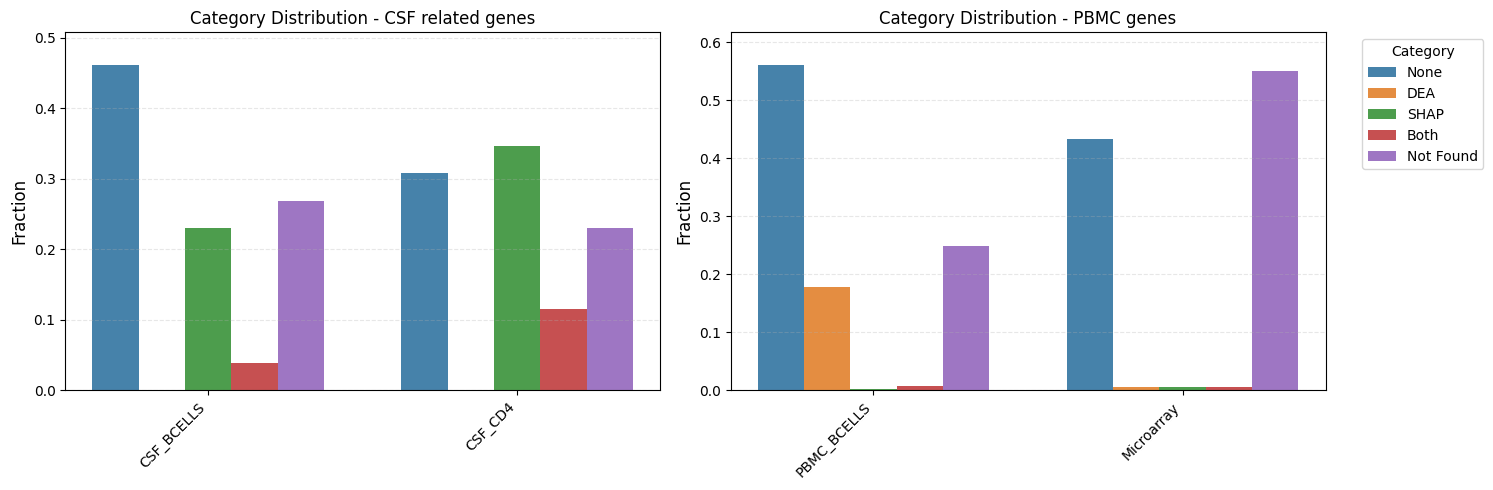

In [67]:
def plot_category_distribution_side_by_side(
    csf_dataframes_dict,
    pbmc_dataframes_dict,
    csf_genes,
    pbmc_genes,
    csf_title='Category Distribution - CSF',
    pbmc_title='Category Distribution - PBMC',
    figsize=(20, 6),
    save_path=None,
    csf_csv_path=None,
    pbmc_csv_path=None
):
    """
    Create two grouped bar plots side by side:
      - Left: CSF datasets
      - Right: PBMC datasets

    Parameters:
    -----------
    csf_dataframes_dict : dict
        Dictionary with CSF dataset names as keys and DataFrames as values
    pbmc_dataframes_dict : dict
        Dictionary with PBMC dataset names as keys and DataFrames as values
    csf_genes : list
        List of genes to filter for CSF
    pbmc_genes : list
        List of genes to filter for PBMC
    csf_title : str
        Title for CSF plot
    pbmc_title : str
        Title for PBMC plot
    figsize : tuple
        Figure size (width, height)
    save_path : str, optional
        Path to save the combined figure
    csf_csv_path : str, optional
        Path to save CSF gene classifications CSV
    pbmc_csv_path : str, optional
        Path to save PBMC gene classifications CSV

    Returns:
    --------
    fig : matplotlib figure
    (ax1, ax2) : tuple of axes
    csf_classification_df : pd.DataFrame
    pbmc_classification_df : pd.DataFrame
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd
    
    # Helper function to process data for one panel
    def process_panel_data(dataframes_dict, genes_of_interest, csv_path=None):
        # Create classification dataframe
        classification_data = []
        for gene in genes_of_interest:
            gene_row = {'Gene': gene}
            for name, df in dataframes_dict.items():
                gene_data = df[df['Gene'] == gene]
                if len(gene_data) > 0:
                    category = gene_data['Category'].fillna('None').iloc[0]
                else:
                    category = 'Not Found'
                gene_row[name] = category
            classification_data.append(gene_row)
        
        classification_df = pd.DataFrame(classification_data)
        
        # Save CSV if path provided
        if csv_path is not None:
            classification_df.to_csv(csv_path, index=False)
            print(f"Gene classifications saved as '{csv_path}'")
        
        # Count categories
        fractions_dict = {}
        for name in dataframes_dict.keys():
            counts = classification_df[name].value_counts()
            
            # Ensure all 5 categories are present
            for cat in ['None', 'DEA', 'SHAP', 'Both', 'Not Found']:
                if cat not in counts:
                    counts[cat] = 0
            
            fractions_dict[name] = counts / counts.sum()
        
        return classification_df, fractions_dict
    
    # Process both datasets
    csf_class_df, csf_fractions = process_panel_data(csf_dataframes_dict, csf_genes, csf_csv_path)
    pbmc_class_df, pbmc_fractions = process_panel_data(pbmc_dataframes_dict, pbmc_genes, pbmc_csv_path)
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    categories = ['None', 'DEA', 'SHAP', 'Both', 'Not Found']
    colors = ['#3274A1', '#E1812C', '#3A923A', '#C03D3E', '#9467BD']
    
    # Plot CSF (left panel)
    dataset_names_csf = list(csf_dataframes_dict.keys())
    data_matrix_csf = np.array([
        [csf_fractions[name].get(cat, 0) for name in dataset_names_csf]
        for cat in categories
    ])
    
    n_datasets_csf = len(dataset_names_csf)
    n_categories = len(categories)
    x_csf = np.arange(n_datasets_csf)
    width = 0.15
    offsets = np.arange(n_categories) * width - (n_categories - 1) * width / 2
    
    for i, (category, color) in enumerate(zip(categories, colors)):
        ax1.bar(x_csf + offsets[i], data_matrix_csf[i], width, 
               label=category, color=color, alpha=0.9)
    
    ax1.set_ylabel('Fraction', fontsize=12)
    ax1.set_title(csf_title, fontsize=12)
    ax1.set_xticks(x_csf)
    ax1.set_xticklabels(dataset_names_csf, rotation=45, ha='right')
    ax1.set_ylim(0, max(data_matrix_csf.max() * 1.1, 0.1))
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Plot PBMC (right panel)
    dataset_names_pbmc = list(pbmc_dataframes_dict.keys())
    data_matrix_pbmc = np.array([
        [pbmc_fractions[name].get(cat, 0) for name in dataset_names_pbmc]
        for cat in categories
    ])
    
    n_datasets_pbmc = len(dataset_names_pbmc)
    x_pbmc = np.arange(n_datasets_pbmc)
    
    for i, (category, color) in enumerate(zip(categories, colors)):
        ax2.bar(x_pbmc + offsets[i], data_matrix_pbmc[i], width, 
               label=category, color=color, alpha=0.9)
    
    ax2.set_ylabel('Fraction', fontsize=12)
    ax2.set_title(pbmc_title, fontsize=12)
    ax2.set_xticks(x_pbmc)
    ax2.set_xticklabels(dataset_names_pbmc, rotation=45, ha='right')
    ax2.set_ylim(0, max(data_matrix_pbmc.max() * 1.1, 0.1))
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Single legend for both plots
    ax2.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Combined plot saved as '{save_path}'")
    
    # Print summary
    print("\nCSF filtered dataset sizes (genes found):")
    for name, df in csf_dataframes_dict.items():
        count = len(df[df['Gene'].isin(csf_genes)])
        print(f"  {name}: {count} genes")
    
    print("\nPBMC filtered dataset sizes (genes found):")
    for name, df in pbmc_dataframes_dict.items():
        count = len(df[df['Gene'].isin(pbmc_genes)])
        print(f"  {name}: {count} genes")
    
    return fig, (ax1, ax2), csf_class_df, pbmc_class_df


# Example usage:

csf_datasets = {
    'CSF_BCELLS': CSF_BCELLS,
    'CSF_CD4': CSF_CD4
}

pbmc_datasets = {
    'PBMC_BCELLS': PBMC_BCELLS,
    'Microarray': MICROARRAY
}

fig, (ax1, ax2), csf_df, pbmc_df = plot_category_distribution_side_by_side(
    csf_dataframes_dict=csf_datasets,
    pbmc_dataframes_dict=pbmc_datasets,
    csf_genes=list(set(csf_genes)),
    pbmc_genes=list(set(pbmc_genes)),
    csf_title='Category Distribution - CSF related genes',
    pbmc_title='Category Distribution - PBMC genes',
    save_path='combined_blood_genes_distribution.png',
    csf_csv_path='csf_blood_genes_classification.csv',
    pbmc_csv_path='pbmc_blood_genes_classification.csv', 
         figsize=(15,5)

)

plt.show()



Plot saved as 'single_axis_multi_background.png'

Filtered dataset sizes (per background):

Background 'csf' (26 genes):

Background 'blood' (369 genes):

Background 'merged' (383 genes):
  CSF_BCELLS: 274 genes
  CSF_CD4: 291 genes
  PBMC B-cells: 286 genes
  Microarray: 173 genes


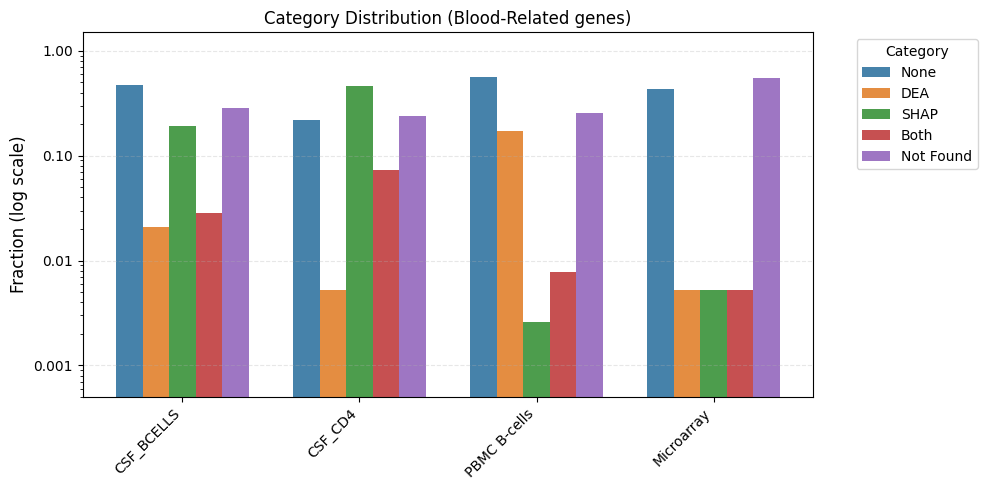

In [33]:
def plot_category_distribution_single_axis_multi_background(
    dataframes_dict,
    dataset_to_background,
    backgrounds,
    title='Category Distribution (mixed backgrounds)',
    figsize=(12, 6),
    save_path=None,
    log_scale=False
):
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd
    from collections import defaultdict

    categories = ['None', 'DEA', 'SHAP', 'Both', 'Not Found']
    colors = ['#3274A1', '#E1812C', '#3A923A', '#C03D3E', '#9467BD']

    classification_dict = {}
    fractions_per_dataset = {}

    for bg_key, genes_of_interest in backgrounds.items():
        classification_data = []
        for gene in genes_of_interest:
            gene_row = {'Gene': gene}
            for ds_name, df in dataframes_dict.items():
                if dataset_to_background.get(ds_name) != bg_key:
                    continue
                gene_data = df[df['Gene'] == gene]
                if len(gene_data) > 0:
                    category = gene_data['Category'].fillna('None').iloc[0]
                else:
                    category = 'Not Found'
                gene_row[ds_name] = category
            classification_data.append(gene_row)

        classification_df = pd.DataFrame(classification_data)
        classification_dict[bg_key] = classification_df

        for ds_name in dataframes_dict.keys():
            if dataset_to_background.get(ds_name) != bg_key:
                continue
            if ds_name not in classification_df.columns:
                continue
            counts = classification_df[ds_name].value_counts()
            for cat in categories:
                if cat not in counts:
                    counts[cat] = 0
            fractions_per_dataset[ds_name] = counts / counts.sum()

    dataset_names = list(fractions_per_dataset.keys())
    n_datasets = len(dataset_names)
    n_categories = len(categories)

    data_matrix = np.array([
        [fractions_per_dataset[ds].get(cat, 0) for ds in dataset_names]
        for cat in categories
    ])

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(n_datasets)
    width = 0.15
    offsets = np.arange(n_categories) * width - (n_categories - 1) * width / 2

    for i, (category, color) in enumerate(zip(categories, colors)):
        vals = data_matrix[i].copy()
        if log_scale:
            vals = np.where(vals == 0, 1e-4, vals)
        ax.bar(x + offsets[i], vals, width,
               label=category, color=color, alpha=0.9)

    ax.set_ylabel('Fraction (log scale)' if log_scale else 'Fraction', fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(dataset_names, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

    if log_scale:
        ax.set_yscale('log')
        ax.set_ylim(5e-4, 1.5)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(
            lambda val, _: f'{val:.3f}' if val < 0.01 else f'{val:.2f}'
        ))
    else:
        ax.set_ylim(0, max(data_matrix.max() * 1.1, 0.1))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved as '{save_path}'")

    print("\nFiltered dataset sizes (per background):")
    for bg_key, genes in backgrounds.items():
        print(f"\nBackground '{bg_key}' ({len(genes)} genes):")
        for ds_name, df in dataframes_dict.items():
            if dataset_to_background.get(ds_name) != bg_key:
                continue
            count = len(df[df['Gene'].isin(genes)])
            print(f"  {ds_name}: {count} genes")

    return fig, ax, classification_dict


# ── Call-site ────────────────────────────────────────────────────────────────

csf_genes    = list(set(csf["Official Symbol of Gene"].tolist()))
blood_genes  = list(set(blood["Official Symbol of Gene"].tolist()))
merged_genes = list(set(csf_genes) | set(blood_genes))

dataframes_dict = {
    'CSF_BCELLS':   CSF_BCELLS,
    'CSF_CD4':      CSF_CD4,
    'PBMC B-cells': PBMC_BCELLS,
    'Microarray':   MICROARRAY
}

backgrounds = {
    'csf':    csf_genes,
    'blood':  blood_genes,
    'merged': merged_genes
}

dataset_to_background = {
    'CSF_BCELLS':   'merged',
    'CSF_CD4':      'merged',
    'PBMC B-cells': 'merged',
    'Microarray':   'merged'
}

fig, ax, class_dict = plot_category_distribution_single_axis_multi_background(
    dataframes_dict=dataframes_dict,
    dataset_to_background=dataset_to_background,
    backgrounds=backgrounds,
    title='Category Distribution (Blood-Related genes)',
    save_path='single_axis_multi_background.png',
    figsize=(10, 5),
    log_scale=True
)

plt.show()
